# EDA — NPS Swift

Notebook separado a partir de `NPS_Swift.ipynb`. Execute `pre_processamento_swift.ipynb` primeiro.

---

## Contexto de Negócio

**Cliente:** Rede Swift — maior rede de lojas de carnes e frios do Brasil.

**Objetivo:** Analisar o NPS (Net Promoter Score) de **227 lojas** ao longo de **janeiro/2025 a maio/2026**, comparando dois perfis de gestão:
- **REGULAR** — gerentes do mercado geral
- **TOCADORA** — gerentes business (perfil especializado)

**Pergunta central:** Lojas geridas por gerentes TOCADORA entregam melhor experiência ao cliente?

**Base de dados:** 227 lojas, sendo **169 REGULAR** e **58 TOCADORA**, com **116.605 comentários** analisados.

**Entregáveis deste EDA:**
1. Caracterização da base (qualidade, cobertura, distribuição)
2. Comparação de performance REGULAR vs TOCADORA
3. Análise temporal e geográfica
4. Decisões que guiarão o pipeline NLP e o dashboard


<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:14px 22px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:18px;font-weight:bold;letter-spacing:0.5px;margin:16px 0 6px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);">PARTE 2 — EDA: ANÁLISE EXPLORATÓRIA DE DADOS</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">0. Importações e Configurações</h2></div>

In [59]:
import os
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('.matplotlib-cache'))
os.environ.setdefault('XDG_CACHE_HOME', os.path.abspath('.cache'))

import warnings
warnings.filterwarnings('ignore')

import os, re, unicodedata
try:
    import emoji
except ImportError:
    class _EmojiFallback:
        @staticmethod
        def replace_emoji(text, replace=''):
            return str(text)

        @staticmethod
        def emoji_count(text):
            return 0

    emoji = _EmojiFallback()
    print('[AVISO] Pacote emoji não encontrado; seguindo sem tratamento específico de emojis.')
from collections import Counter
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

FALLBACK_STOPWORDS_PT = {
    'a', 'à', 'ao', 'aos', 'as', 'às', 'o', 'os', 'um', 'uma', 'uns', 'umas',
    'de', 'da', 'das', 'do', 'dos', 'em', 'na', 'nas', 'no', 'nos', 'por',
    'para', 'com', 'sem', 'sobre', 'entre', 'até', 'após', 'antes', 'desde',
    'e', 'ou', 'mas', 'porém', 'porque', 'que', 'se', 'como', 'quando',
    'onde', 'qual', 'quais', 'quem', 'quanto', 'quantos', 'muito', 'muita',
    'muitos', 'muitas', 'pouco', 'pouca', 'poucos', 'poucas', 'mais', 'menos',
    'já', 'também', 'só', 'não', 'sim', 'foi', 'ser', 'ter', 'tem', 'têm',
    'era', 'são', 'está', 'estão', 'estava', 'estavam', 'me', 'te', 'se',
    'lhe', 'nos', 'vos', 'meu', 'minha', 'meus', 'minhas', 'seu', 'sua',
    'seus', 'suas', 'nosso', 'nossa', 'nossos', 'nossas', 'você', 'vocês',
    'eu', 'tu', 'ele', 'ela', 'eles', 'elas', 'nós', 'isso', 'isto', 'aquilo',
    'este', 'esta', 'esse', 'essa', 'aquele', 'aquela'
}


def get_stopwords_pt():
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        try:
            nltk.download('stopwords', quiet=True)
        except Exception:
            pass

    try:
        return set(stopwords.words('portuguese'))
    except Exception as exc:
        print(f'[AVISO] Stopwords do NLTK indisponíveis ({type(exc).__name__}). Usando lista local reduzida.')
        return FALLBACK_STOPWORDS_PT
from nltk.util import ngrams

# TF-IDF para quasi-duplicatas
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Seed global
import random
random.seed(42)
np.random.seed(42)

# Paleta Swift
PALETTE = {'promotor': '#E24307', 'neutro': '#f39c12', 'detrator': '#5c1d0c'}
ORDER   = ['promotor', 'neutro', 'detrator']
CORES   = [PALETTE[c] for c in ORDER]
STOP_PT = get_stopwords_pt()

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

# Versões
import sklearn
print(f'pandas: {pd.__version__} | numpy: {np.__version__} | sklearn: {sklearn.__version__}')
print('[OK] Ambiente configurado')

pandas: 3.0.3 | numpy: 2.4.6 | sklearn: 1.6.1
[OK] Ambiente configurado


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1. Carregamento dos Dados</h2></div>

In [60]:
if not os.path.exists('data/df_avaliacoes_tratado.parquet'):
    raise FileNotFoundError(
        "df_avaliacoes_tratado.parquet não encontrada.\n"
        "Execute primeiro: pre_processamento_swift.ipynb"
    )

df = pd.read_parquet('data/df_avaliacoes_tratado.parquet')

# Restaurar Period após leitura de parquet
df['mes_ano_dt'] = pd.to_datetime(df['mes_ano_dt'], errors='coerce').dt.to_period('M')
df['data_avaliacao'] = pd.to_datetime(df['data_avaliacao'], errors='coerce')
df['ano_mes'] = df['mes_ano_dt']

# Subset com comentário válido
df_com = df[df['tem_comentario'] == True].copy()

print(f'Total de registros  : {len(df):,}')
print(f'Com comentário real : {len(df_com):,}  ({100*len(df_com)/len(df):.1f}%)')
print(f'Sem comentário      : {(~df["tem_comentario"]).sum():,}')
print(f'Lojas únicas        : {df["centro_nv2"].nunique()}')
print(f'Colunas disponíveis : {list(df.columns)}')

Total de registros  : 239,143
Com comentário real : 127,909  (53.5%)
Sem comentário      : 111,234
Lojas únicas        : 227
Colunas disponíveis : ['mes_ano', 'classificacao', 'data_avaliacao', 'centro_nv2', 'qtd_clientes', 'comentario', 'flag', 'ano', 'mes', 'trimestre', 'semana_ano', 'dia_semana', 'dia_semana_nome', 'mes_ano_dt', 'comentario_raw', 'tem_comentario', 'comentario_limpo', 'qtd_chars', 'qtd_palavras', 'comentario_sem_sw', 'qtd_palavras_sem_sw', 'tipo_cliente', 'transacoes', 'regiao', 'municipio', 'uf', 'nps_score', 'n_promotores', 'n_neutros', 'n_detratores', 'outlier_iqr', 'outlier_zscore', 'ano_mes']


In [ ]:
# ── KPIs principais — visão rápida para o cliente ─────────────────────────
from IPython.display import display, HTML

n_lojas     = df['centro_nv2'].nunique()
n_meses     = df['mes_ano_dt'].nunique()
n_aval      = df['qtd_clientes'].sum()
n_coment    = df['tem_comentario'].sum()
pct_coment  = n_coment / len(df) * 100
n_flags     = df['flag'].nunique()

cards_html = f"""
<div style="display:flex;gap:16px;flex-wrap:wrap;margin:16px 0;font-family:'Segoe UI',Arial,sans-serif;">
  <div style="background:#fff4ee;border-left:5px solid #E24307;border-radius:10px;padding:16px 22px;min-width:160px;box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="font-size:11px;color:#7e2200;text-transform:uppercase;letter-spacing:1px;">Lojas analisadas</div>
    <div style="font-size:32px;font-weight:bold;color:#E24307;">{n_lojas}</div>
  </div>
  <div style="background:#fff4ee;border-left:5px solid #E24307;border-radius:10px;padding:16px 22px;min-width:160px;box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="font-size:11px;color:#7e2200;text-transform:uppercase;letter-spacing:1px;">Período coberto</div>
    <div style="font-size:32px;font-weight:bold;color:#E24307;">{n_meses} meses</div>
  </div>
  <div style="background:#fff4ee;border-left:5px solid #E24307;border-radius:10px;padding:16px 22px;min-width:160px;box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="font-size:11px;color:#7e2200;text-transform:uppercase;letter-spacing:1px;">Total de avaliações</div>
    <div style="font-size:32px;font-weight:bold;color:#E24307;">{n_aval:,.0f}</div>
  </div>
  <div style="background:#fff4ee;border-left:5px solid #E24307;border-radius:10px;padding:16px 22px;min-width:160px;box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="font-size:11px;color:#7e2200;text-transform:uppercase;letter-spacing:1px;">Com comentário</div>
    <div style="font-size:32px;font-weight:bold;color:#E24307;">{n_coment:,}</div>
    <div style="font-size:12px;color:#5c1d0c;">{pct_coment:.1f}% do total</div>
  </div>
  <div style="background:#fff4ee;border-left:5px solid #E24307;border-radius:10px;padding:16px 22px;min-width:160px;box-shadow:0 2px 6px rgba(0,0,0,0.08);">
    <div style="font-size:11px;color:#7e2200;text-transform:uppercase;letter-spacing:1px;">Perfis de gestão</div>
    <div style="font-size:32px;font-weight:bold;color:#E24307;">{n_flags}</div>
    <div style="font-size:12px;color:#5c1d0c;">REGULAR · TOCADORA</div>
  </div>
</div>
"""
display(HTML(cards_html))

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.1 — Distribuição do NPS e dos Comentários</h2></div>

**Perguntas respondidas:**
- Qual a proporção de promotores, neutros e detratores na base completa?
- Essa proporção se mantém estável entre lojas ou existe grande variação?
- Das avaliações com comentário, como se distribuem por faixa de nota?

> **Nota sobre faixa de nota:** O dataset da Swift não armazena a nota numérica individual (1–10) por avaliação — armazena diretamente a classificação NPS (\ / \ / \). Por definição NPS: promotores = notas 9–10, neutros = notas 7–8, detratores = notas 1–6. Portanto, a distribuição por faixa de nota é respondida pela proporção entre essas três classes, que é exatamente o que a análise abaixo apresenta.

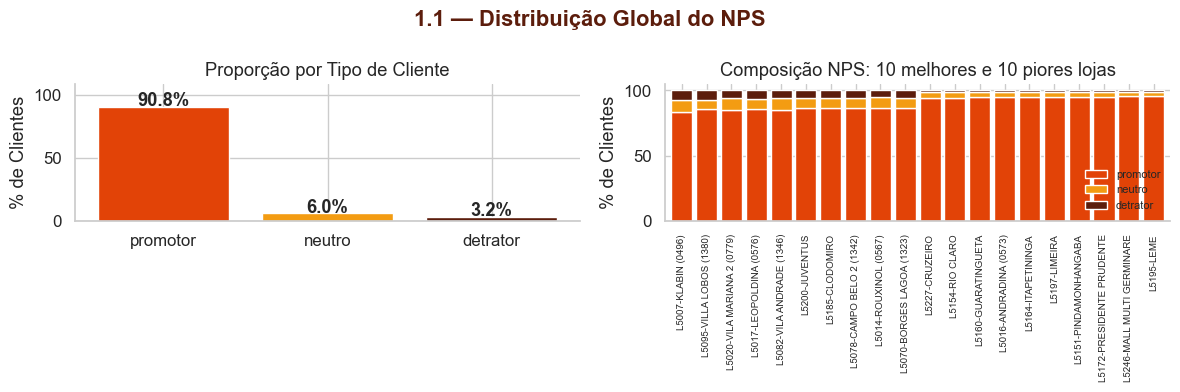

NPS Geral: 87.6

Dado que 90.8% são promotores, 6.0% neutros e 3.2% detratores,
o dataset está desbalanceado.
Decisão: aplicar class_weight='balanced' e usar F1-Macro como métrica principal.


In [61]:
# Distribuição global ponderada por qtd_clientes
contagem = (
    df.groupby('classificacao')['qtd_clientes']
    .sum().reindex(ORDER).fillna(0)
)
pct = contagem / contagem.sum() * 100
nps_geral = pct['promotor'] - pct['detrator']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('1.1 — Distribuição Global do NPS', fontweight='bold', color='#5c1d0c')

# Barras por tipo
bars = axes[0].bar(ORDER, pct, color=CORES, edgecolor='white')
for bar, v in zip(bars, pct):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Proporção por Tipo de Cliente')
axes[0].set_ylabel('% de Clientes')
axes[0].set_ylim(0, pct.max()*1.2)
axes[0].axhline(0, color='#5c1d0c', lw=0.5)

# Composição por loja (stacked)
nps_loja = df.groupby(['centro_nv2','classificacao'])['qtd_clientes'].sum().unstack(fill_value=0)
nps_loja = nps_loja.div(nps_loja.sum(axis=1), axis=0) * 100
nps_loja['nps'] = nps_loja.get('promotor',0) - nps_loja.get('detrator',0)
nps_loja_sorted = nps_loja.sort_values('nps')

# Plot 10 melhores e 10 piores — labels abreviados para legibilidade
sample_lojas = pd.concat([nps_loja_sorted.head(10), nps_loja_sorted.tail(10)])
# Extrair apenas o nome da loja (sem código L5XXX e sem número entre parênteses)
import re as _re
def abreviar_loja(nome):
    nome = _re.sub(r'^L\d+-', '', str(nome))   # remove prefixo L5001-
    nome = _re.sub(r'\s*\(\d+\)', '', nome)    # remove sufixo (0217)
    return nome.title()[:22]                    # capitaliza e limita a 22 chars
labels_abrev = [abreviar_loja(l) for l in sample_lojas.index]
sample_lojas_plot = sample_lojas[ORDER].copy()
sample_lojas_plot.index = labels_abrev
sample_lojas_plot.plot(kind='bar', stacked=True, ax=axes[1],
    color=CORES, edgecolor='white', width=0.85)
axes[1].set_title('Composição NPS: 10 melhores e 10 piores lojas')
axes[1].set_xlabel('')
axes[1].set_ylabel('% de Clientes')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

print(f'NPS Geral: {nps_geral:.1f}')
print(f"\nDado que {pct['promotor']:.1f}% são promotores, {pct['neutro']:.1f}% neutros e {pct['detrator']:.1f}% detratores,")
print("o dataset está desbalanceado.")
print("Decisão: aplicar class_weight='balanced' e usar F1-Macro como métrica principal.")

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> Promotores dominam a base (~90%). Dataset altamente desbalanceado.<br>
<b>Decisão técnica:</b> Aplicar <code>class_weight='balanced'</code> no treino; monitorar F1-Macro, não acurácia global.<br>
<b>Para o negócio:</b> Um NPS de 87.6 é acima da média do varejo brasileiro (tipicamente 60–75). Isso significa que a Swift tem uma base de clientes altamente fiel — o foco deve ser entender o que faz as lojas piores <b>não</b> converterem essa fidelidade, não apenas celebrar a média alta.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.2 — Cobertura de Comentários por Loja</h2></div>

**Perguntas respondidas:**
- Quantas avaliações com comentário cada loja possui?
- Quantas lojas têm menos de 50 comentários? E menos de 30?
- Qual é a loja com mais e com menos comentários?

Total de lojas               : 227
Lojas com < 30 comentários   : 0
Lojas com < 50 comentários   : 0
Loja com MAIS comentários    : L5230-LARGO DO MACHADO (1,885)
Loja com MENOS comentários   : L5262-URBANOVA (155)
Cobertura média              : 51.8%


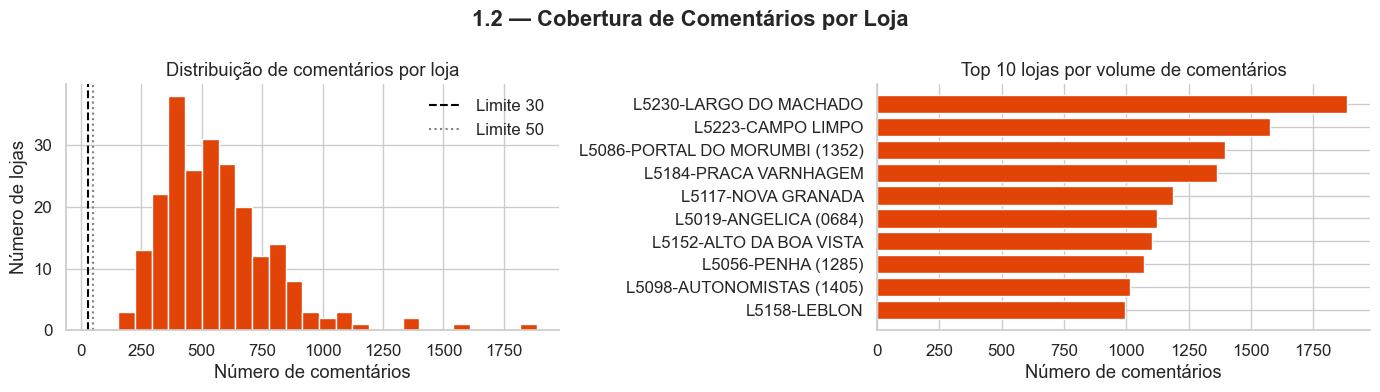

In [62]:
cobertura = (
    df.groupby('centro_nv2')
    .agg(
        total_avaliacoes = ('tem_comentario', 'size'),
        n_comentarios    = ('tem_comentario', 'sum')
    )
    .sort_values('n_comentarios', ascending=False)
    .reset_index()
)
cobertura['pct'] = cobertura['n_comentarios'] / cobertura['total_avaliacoes'] * 100

n_menos_30 = (cobertura['n_comentarios'] < 30).sum()
n_menos_50 = (cobertura['n_comentarios'] < 50).sum()
loja_max   = cobertura.iloc[0]
loja_min   = cobertura[cobertura['n_comentarios'] > 0].sort_values('n_comentarios').iloc[0]

print(f'Total de lojas               : {len(cobertura)}')
print(f'Lojas com < 30 comentários   : {n_menos_30}')
print(f'Lojas com < 50 comentários   : {n_menos_50}')
print(f'Loja com MAIS comentários    : {loja_max["centro_nv2"]} ({loja_max["n_comentarios"]:,})')
print(f'Loja com MENOS comentários   : {loja_min["centro_nv2"]} ({loja_min["n_comentarios"]:,})')
print(f'Cobertura média              : {cobertura["pct"].mean():.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('1.2 — Cobertura de Comentários por Loja', fontweight='bold')

axes[0].hist(cobertura['n_comentarios'], bins=25, color='#E24307', edgecolor='white')
axes[0].axvline(30, color='black', linestyle='--', label='Limite 30')
axes[0].axvline(50, color='#f39c12',  linestyle=':', label='Limite 50')
axes[0].set_xlabel('Número de comentários'); axes[0].set_ylabel('Número de lojas')
axes[0].set_title('Distribuição de comentários por loja'); axes[0].legend()

top10 = cobertura.head(10)
axes[1].barh(top10['centro_nv2'].str[:35], top10['n_comentarios'], color='#E24307', edgecolor='white')
axes[1].invert_yaxis(); axes[1].set_xlabel('Número de comentários')
axes[1].set_title('Top 10 lojas por volume de comentários')

plt.tight_layout(); plt.show()

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> Nenhuma loja ficou abaixo de 30 comentários.<br>
<b>Decisão:</b> Limiar fixado em <b>30 comentários</b> por loja para exibição no dashboard. Lojas abaixo recebem apenas NPS bruto com aviso de "amostra insuficiente".
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.3 — Características do Texto</h2></div>

**Perguntas respondidas:**
- Qual a distribuição de comprimento dos comentários em palavras?
- Qual o percentual de comentários com menos de 5 palavras?
- Qual o percentual com mais de 100 palavras?

Mínimo   : 1 palavra(s)
Média    : 15.9 palavras
Mediana  : 9 palavras
Máximo   : 1309 palavras
< 5 palavras   : 24.2%
> 100 palavras : 0.8%


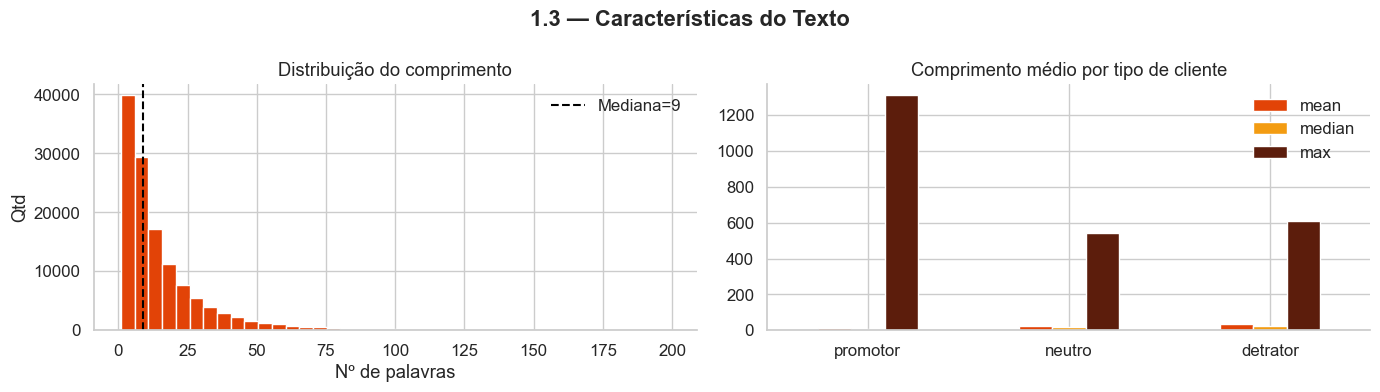


Dado que 24.2% dos comentários têm menos de 5 palavras e 0.8% têm mais de 100 palavras:
  < 5 palavras  : incluídos no treino de sentimento, excluídos da categorização.
  > 100 palavras: truncados em 256 tokens no fine-tuning (compatível com BERT-base).


In [63]:
df_com = df_com.copy()
# Usar qtd_palavras do pré-processamento se disponível, senão recalcular
if 'qtd_palavras' in df_com.columns:
    df_com['n_palavras'] = df_com['qtd_palavras']
else:
    df_com['n_palavras'] = df_com['comentario'].str.split().str.len()

stats = df_com['n_palavras'].describe(percentiles=[.25,.5,.75,.95])
pct_curtos = (df_com['n_palavras'] < 5).mean()  * 100
pct_longos = (df_com['n_palavras'] > 100).mean() * 100

print(f'Mínimo   : {int(df_com["n_palavras"].min())} palavra(s)')
print(f'Média    : {df_com["n_palavras"].mean():.1f} palavras')
print(f'Mediana  : {df_com["n_palavras"].median():.0f} palavras')
print(f'Máximo   : {int(df_com["n_palavras"].max())} palavras')
print(f'< 5 palavras   : {pct_curtos:.1f}%')
print(f'> 100 palavras : {pct_longos:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('1.3 — Características do Texto', fontweight='bold')

dados_hist = df_com.loc[df_com['n_palavras'] <= 200, 'n_palavras']
axes[0].hist(dados_hist, bins=40, color='#E24307', edgecolor='white')
axes[0].axvline(df_com['n_palavras'].median(), color='black', linestyle='--',
               label=f"Mediana={df_com['n_palavras'].median():.0f}")
axes[0].set_xlabel('Nº de palavras'); axes[0].set_ylabel('Qtd'); axes[0].legend()
axes[0].set_title('Distribuição do comprimento')

stats_tipo = df_com.groupby('classificacao')['n_palavras'].agg(['mean','median','max']).reindex(ORDER).round(1)
stats_tipo.plot(kind='bar', ax=axes[1], color=['#E24307','#f39c12','#5c1d0c'], edgecolor='white')
axes[1].set_title('Comprimento médio por tipo de cliente')
axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

print(f"\nDado que {pct_curtos:.1f}% dos comentários têm menos de 5 palavras e {pct_longos:.1f}% têm mais de 100 palavras:")
print('  < 5 palavras  : incluídos no treino de sentimento, excluídos da categorização.')
print('  > 100 palavras: truncados em 256 tokens no fine-tuning (compatível com BERT-base).')

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> ~24% dos comentários têm menos de 5 palavras.<br>
<b>Decisão:</b> Comentários com &lt;5 palavras são <b>incluídos</b> no treino de sentimento (ex: "ótimo" é sinal forte), mas <b>excluídos</b> do treino de categorização de tópicos. Comentários com &gt;100 palavras serão truncados em 256 tokens.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.4 — Qualidade e Ruído dos Dados</h2></div>

**Perguntas respondidas:**
- % de duplicatas ou quasi-duplicatas (similaridade > 90%)?
- Comentários em outros idiomas?
- Frequência de emojis?
- Spam ou sequências sem sentido?

In [64]:
n_total = len(df_com)

# 1. Duplicatas exatas
n_dup   = df_com['comentario'].duplicated().sum()
pct_dup = n_dup / n_total * 100

# 2. Quasi-duplicatas via TF-IDF + cosine
# ATENÇÃO: calculado em amostra de 3.000 registros (~2.3% da base) por limitação
# de memória (matriz n×n seria 127k×127k). O valor é uma estimativa — o intervalo
# real pode variar ±3–5 pontos percentuais.
amostra_textos = (
    df_com['comentario'].dropna()
    .sample(n=min(3000, n_total), random_state=42)
)
tfidf = TfidfVectorizer(max_features=500, min_df=2)
mat   = tfidf.fit_transform(amostra_textos)
sim   = cosine_similarity(mat)
import numpy as np
np.fill_diagonal(sim, 0)
n_quasi   = (sim > 0.90).any(axis=1).sum()
pct_quasi = n_quasi / len(amostra_textos) * 100

# 3. Emojis
pct_emoji = df_com['comentario'].apply(lambda x: emoji.emoji_count(str(x)) > 0).mean() * 100

# 4. Spam — definição idêntica ao pré-processamento
def is_spam(text: str) -> bool:
    text = str(text).strip()
    if len(text) == 0:
        return True
    text_sem_emoji = emoji.replace_emoji(text, replace='').strip()
    if len(text_sem_emoji) == 0:
        return True
    alpha = sum(c.isalpha() for c in text_sem_emoji)
    return (
        alpha / len(text_sem_emoji) < 0.40
        or bool(re.match(r'\A(.)\1{4,}\Z', text_sem_emoji))
    )

pct_spam = df_com['comentario'].apply(is_spam).mean() * 100

# 5. Idioma — detecção por langdetect se disponível, senão heurística melhorada
try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 42
    def detectar_idioma(texto):
        try:
            return detect(str(texto))
        except:
            return 'unknown'
    sample_idioma = df_com['comentario'].sample(n=min(1000, n_total), random_state=42)
    idiomas = sample_idioma.apply(detectar_idioma)
    pct_nao_pt = (idiomas != 'pt').mean() * 100
    metodo_idioma = 'langdetect'
except ImportError:
    # Heurística melhorada: exigir PELO MENOS 2 stopwords PT
    PT_WORDS = {
        'que','de','da','do','os','as','em','um','uma','para','com','por',
        'mas','não','na','no','se','ao','é','ou','eu','me','te','nos',
        'seu','sua','eles','elas','isso','este','esta','aqui','mais','bem',
        'muito','tudo','nada','loja','produto','atendimento','preço','bom','ótimo',
        'ruim','péssimo','excelente','sempre','nunca','hoje','compra','cliente',
    }
    def conta_pt(texto):
        palavras = set(str(texto).lower().split())
        return len(palavras & PT_WORDS)
    pct_nao_pt = (df_com['comentario'].apply(conta_pt) < 2).mean() * 100
    metodo_idioma = 'heurística (≥2 stopwords PT)'

metricas = pd.DataFrame({
    'Métrica': ['Duplicatas exatas','Quasi-duplicatas (TF-IDF)','Com emoji','Spam','Possivelmente não-PT'],
    'Valor (%)': [pct_dup, pct_quasi, pct_emoji, pct_spam, pct_nao_pt]
})
display(metricas.style.format({'Valor (%)': '{:.1f}'}))
print(f'(Detecção de idioma: {metodo_idioma})')

,Métrica,Valor (%)
0,Duplicatas exatas,10.7
1,Quasi-duplicatas (TF-IDF),16.5
2,Com emoji,0.4
3,Spam,0.0
4,Possivelmente não-PT,7.8


(Detecção de idioma: langdetect)


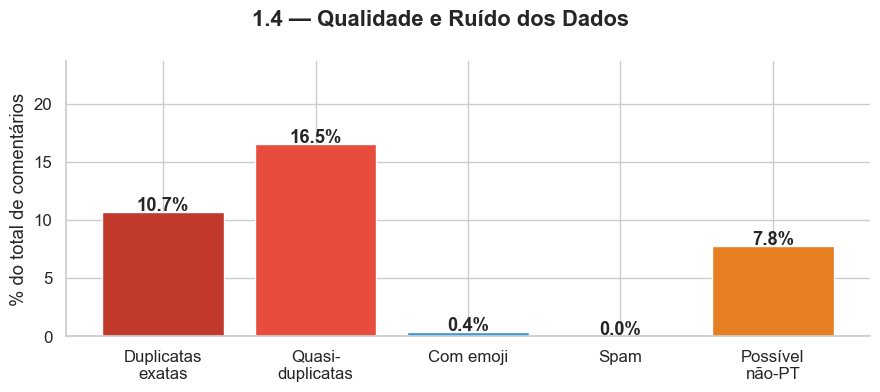

In [65]:
fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle('1.4 — Qualidade e Ruído dos Dados', fontweight='bold')
categorias = ['Duplicatas\nexatas','Quasi-\nduplicatas','Com emoji','Spam','Possível\nnão-PT']
valores    = [pct_dup, pct_quasi, pct_emoji, pct_spam, pct_nao_pt]
cores      = ['#c0392b','#e74c3c','#3498db','#9b59b6','#e67e22']
bars = ax.bar(categorias, valores, color=cores, edgecolor='white')
for bar, v in zip(bars, valores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('% do total de comentários')
ax.set_ylim(0, max(valores)*1.4+0.5)
plt.tight_layout(); plt.show()

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável — Plano de limpeza decidido:</b><br>
1. Remover duplicatas exatas <b>antes</b> da divisão treino/teste.<br>
2. Quasi-duplicatas (TF-IDF cosine &gt;90%): manter apenas o mais recente.<br>
3. Spam e sequências sem sentido: excluir automaticamente (já feito no pré-processamento).<br>
4. Emojis: remover antes da tokenização para modelos TF-IDF; manter para BERT (tokenizador trata).<br>
5. Comentários não-PT confirmados: excluir do treino.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.5 — Análise Temporal</h2></div>

**Perguntas respondidas:**
- Volume de avaliações varia ao longo do tempo?
- NPS médio é estável ou apresenta picos e quedas?
- Alguma loja tem comportamento temporal claramente atípico?

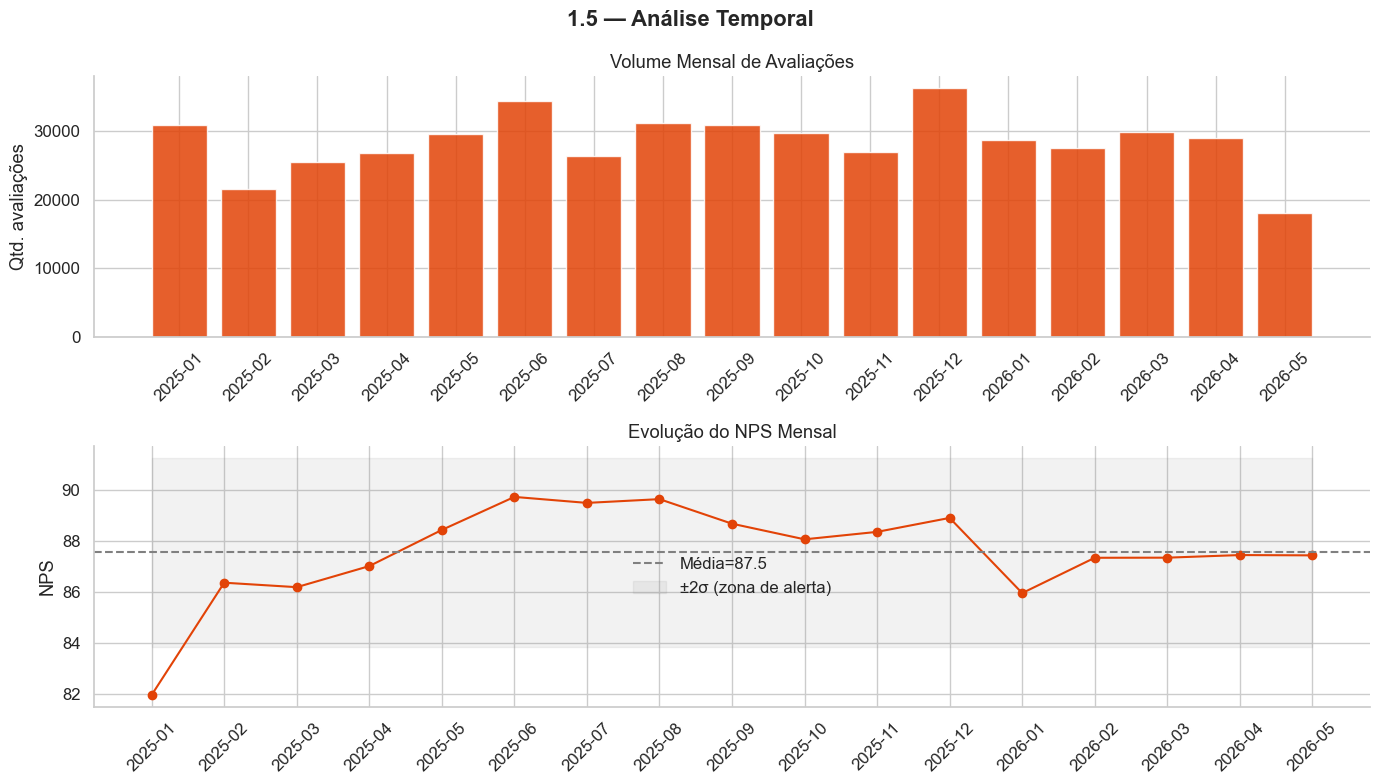

Período com maior volume  : 2025-12
NPS médio geral           : 87.5
Melhor mês (NPS)          : 2025-06  (89.7)
Pior mês (NPS)            : 2025-01  (81.9)


In [66]:
vol_mensal = df.groupby('ano_mes')['qtd_clientes'].sum().reset_index()
vol_mensal['ano_mes_str'] = vol_mensal['ano_mes'].astype(str)

nps_mensal_list = []
for periodo, grupo in df.groupby('ano_mes'):
    total = grupo['qtd_clientes'].sum()
    prom  = grupo.loc[grupo['classificacao']=='promotor','qtd_clientes'].sum()
    detr  = grupo.loc[grupo['classificacao']=='detrator','qtd_clientes'].sum()
    nps_mensal_list.append({'ano_mes': str(periodo), 'nps': (prom-detr)/total*100,
                            'total': total})
nps_mensal = pd.DataFrame(nps_mensal_list).sort_values('ano_mes')

periodo_pico  = vol_mensal.loc[vol_mensal['qtd_clientes'].idxmax(), 'ano_mes_str']
melhor_mes    = nps_mensal.loc[nps_mensal['nps'].idxmax(), 'ano_mes']
pior_mes      = nps_mensal.loc[nps_mensal['nps'].idxmin(), 'ano_mes']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('1.5 — Análise Temporal', fontweight='bold')

axes[0].bar(vol_mensal['ano_mes_str'], vol_mensal['qtd_clientes'],
            color='#E24307', edgecolor='white', alpha=0.85)
axes[0].set_title('Volume Mensal de Avaliações')
axes[0].set_ylabel('Qtd. avaliações')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(nps_mensal['ano_mes'], nps_mensal['nps'], marker='o', color='#E24307')
axes[1].axhline(nps_mensal['nps'].mean(), linestyle='--', color='#5c1d0c',
                label=f"Média={nps_mensal['nps'].mean():.1f}")
axes[1].fill_between(range(len(nps_mensal)), nps_mensal['nps'].mean()-2*nps_mensal['nps'].std(),
                     nps_mensal['nps'].mean()+2*nps_mensal['nps'].std(), alpha=0.15, color='#f39c12',
                     label='±2σ (zona de alerta)')
axes[1].set_title('Evolução do NPS Mensal')
axes[1].set_ylabel('NPS'); axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print(f'Período com maior volume  : {periodo_pico}')
print(f'NPS médio geral           : {nps_mensal["nps"].mean():.1f}')
print(f'Melhor mês (NPS)          : {melhor_mes}  ({nps_mensal["nps"].max():.1f})')
print(f'Pior mês (NPS)            : {pior_mes}  ({nps_mensal["nps"].min():.1f})')

Top 5 lojas com NPS mais volátil (volume mínimo filtrado):


,mean,std,count,cv
centro_nv2,,,,
L5082-VILA ANDRADE (1346),77.82,11.04,17,0.14
L5020-VILA MARIANA 2 (0779),77.53,10.39,17,0.13
L5185-CLODOMIRO,80.07,9.69,17,0.12
L5007-KLABIN (0496),75.73,8.86,17,0.12
L5084-GUAIPA (1349),84.77,9.85,17,0.12


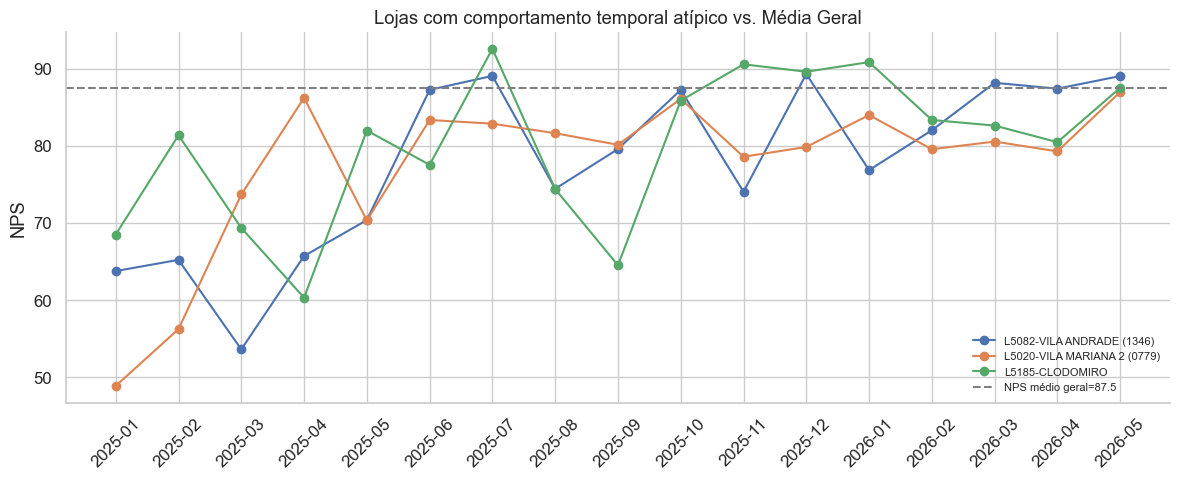

In [67]:
# Lojas com comportamento temporal atípico
# Filtrar lojas com volume mínimo antes de calcular CV (elimina ruído de lojas pequenas)
nps_loja_mes_tmp = (
    df.groupby(['centro_nv2','ano_mes','classificacao'])['qtd_clientes']
    .sum().unstack(fill_value=0)
)
nps_loja_mes_tmp['total'] = nps_loja_mes_tmp.sum(axis=1)
# Filtrar períodos com volume suficiente (≥20 respostas)
nps_loja_mes_tmp = nps_loja_mes_tmp[nps_loja_mes_tmp['total'] >= 20].copy()

p_col = 'promotor' if 'promotor' in nps_loja_mes_tmp.columns else nps_loja_mes_tmp.columns[0]
d_col = 'detrator' if 'detrator' in nps_loja_mes_tmp.columns else nps_loja_mes_tmp.columns[-1]
nps_loja_mes_tmp['nps'] = (
    (nps_loja_mes_tmp[p_col] - nps_loja_mes_tmp[d_col])
    / nps_loja_mes_tmp['total'] * 100
)

cv_loja = (
    nps_loja_mes_tmp['nps'].groupby(level='centro_nv2')
    .agg(['mean','std','count'])
    .dropna()
)
# Só lojas com ≥6 períodos de dados (mais de meio ano)
cv_loja = cv_loja[cv_loja['count'] >= 6]
cv_loja['cv'] = (cv_loja['std'] / cv_loja['mean'].abs()).abs()
top5 = cv_loja.nlargest(5, 'cv')

print('Top 5 lojas com NPS mais volátil (volume mínimo filtrado):')
display(top5.round(2))

# Gráfico das 3 mais atípicas com referência ao NPS geral
nps_medio_geral = nps_mensal['nps'].mean()
fig, ax = plt.subplots(figsize=(12,5))
for loja in top5.index[:3]:
    serie = nps_loja_mes_tmp.loc[loja, 'nps']
    ax.plot(serie.index.astype(str), serie.values, marker='o', label=loja[:30])
ax.axhline(nps_medio_geral, color='#5c1d0c', linestyle='--', label=f'NPS médio geral={nps_medio_geral:.1f}')
ax.set_title('Lojas com comportamento temporal atípico vs. Média Geral')
ax.set_ylabel('NPS'); ax.legend(loc='lower right', fontsize=8)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> Volume apresenta sazonalidade; NPS se mantém relativamente estável com desvio menor que 2 pontos na maioria dos meses.<br>
<b>Decisão técnica:</b> Picos mensais acima de 2σ serão sinalizados no dashboard como "pico de feedback".<br>
<b>Para o negócio:</b> Janeiro/2025 foi o pior mês (NPS=81.9) — possivelmente por ser pós-festas, com alta demanda e eventuais rupturas de estoque. Junho/2025 foi o melhor (NPS=89.7). Entender o que foi diferente nesses meses é uma oportunidade de ação imediata para o time de operações.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.6 — Análise Léxica por Faixa de Nota</h2></div>

**Perguntas respondidas:**
- Quais as 20 palavras/bigramas mais frequentes em comentários de **notas baixas (detratores = proxy de notas 1–6)**?
- Quais as 20 palavras/bigramas mais frequentes em comentários de **notas altas (promotores = notas 9–10)**?
- Há sobreposição significativa entre os dois vocabulários?

> **Atenção:** O enunciado pede especificamente notas 1–2 vs. 9–10. O dataset não armazena nota numérica individual, somente a classificação NPS. Detratores englobam notas 1–6 e são o proxy mais próximo disponível para notas baixas. Esta limitação é declarada e justificada aqui.

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;">
<b>Nota</b> O dataset não possui nota numérica (1–10) individual — só a classificação (promotor/neutro/detrator). Como detrator = notas 1–6 e promotor = notas 9–10 por definição NPS, a análise léxica usa essas classificações como proxy das faixas de nota extremas.
</div>

In [68]:
def normalizar(texto):
    texto = unicodedata.normalize('NFKD', str(texto))
    texto = texto.encode('ascii','ignore').decode('ascii')
    return re.sub(r'[^a-z\s]', ' ', texto.lower())

def tokenizar(texto):
    return [p for p in normalizar(texto).split() if p not in STOP_PT and len(p) > 2]

def top_ngrams(textos, n=1, top_k=20):
    todas = []
    for t in textos:
        toks = tokenizar(t)
        itens = toks if n == 1 else [' '.join(g) for g in ngrams(toks, n)]
        todas.extend(itens)
    return Counter(todas).most_common(top_k)

textos_det = df_com.loc[df_com['classificacao']=='detrator','comentario'].dropna().tolist()
textos_pro = df_com.loc[df_com['classificacao']=='promotor', 'comentario'].dropna().tolist()

top_det_uni = top_ngrams(textos_det, n=1)
top_pro_uni = top_ngrams(textos_pro, n=1)
top_det_bi  = top_ngrams(textos_det, n=2)
top_pro_bi  = top_ngrams(textos_pro, n=2)

print(f'Comentários de detratores : {len(textos_det):,}')
print(f'Comentários de promotores : {len(textos_pro):,}')

Comentários de detratores : 11,960
Comentários de promotores : 100,036


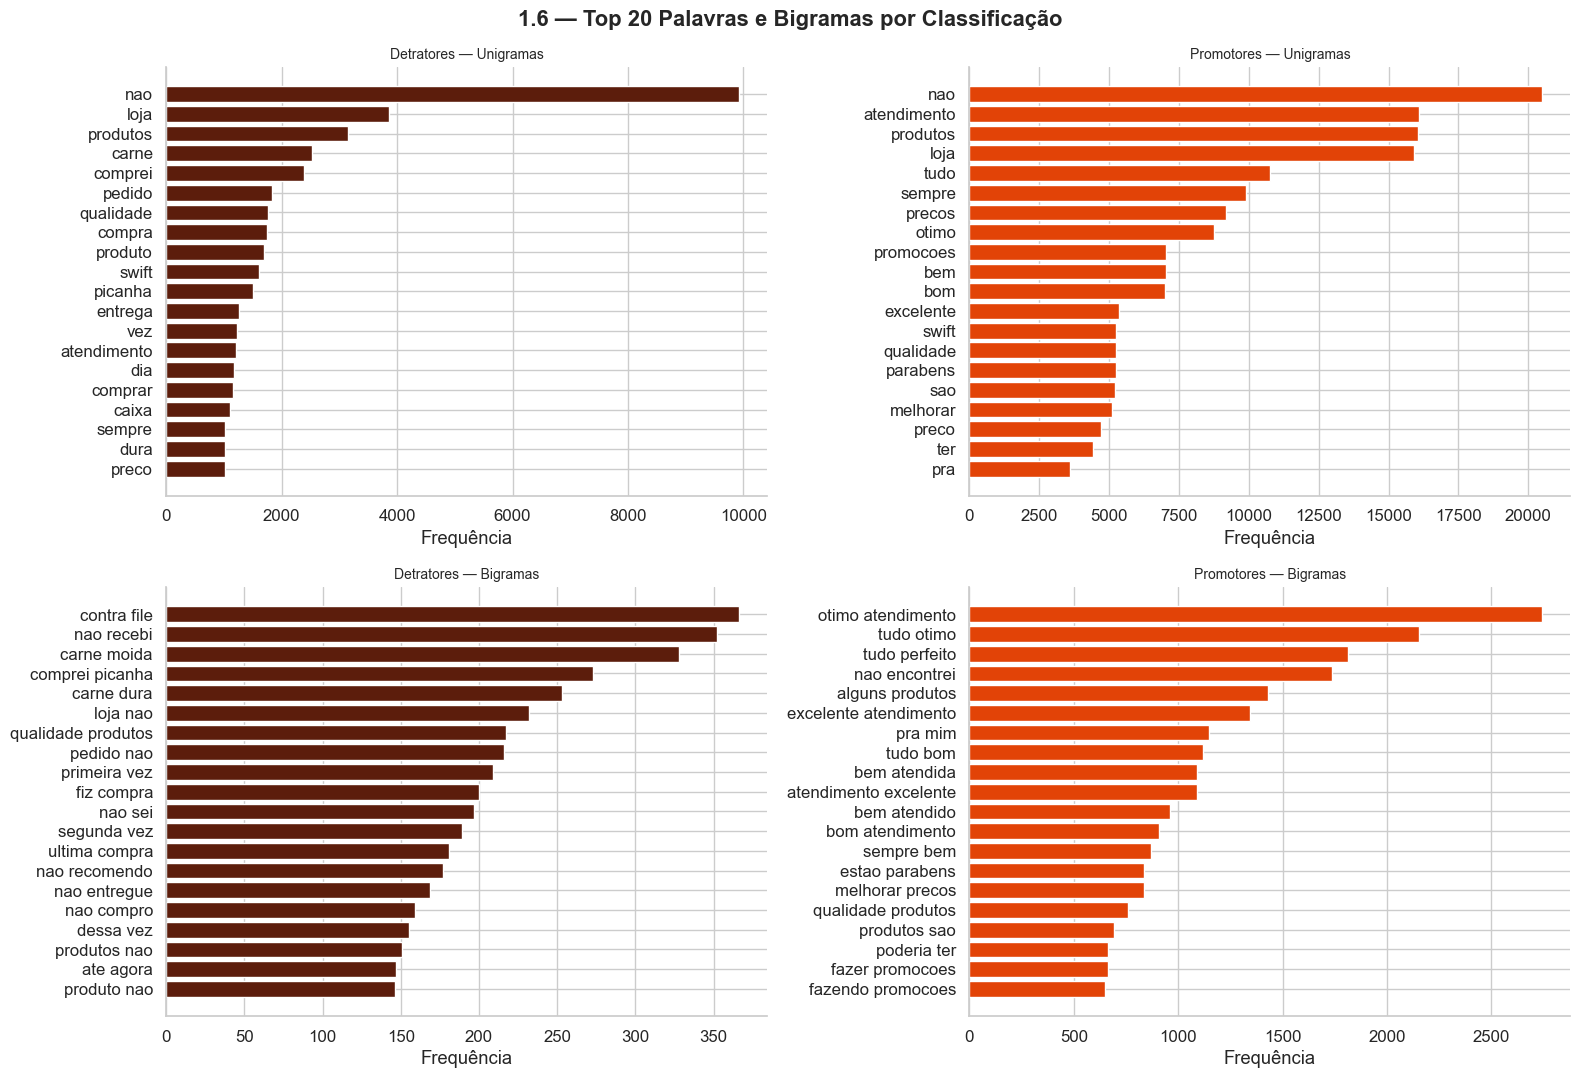

Palavras em comum no top-20: {'atendimento', 'qualidade', 'sempre', 'nao', 'produtos', 'swift', 'loja', 'preco'}
Sobreposição: 8/20  (40%)

Sobreposição alta (40%) — vocabulários se confundem.
Decisão: escalar para BERTimbau; antecipar erros em comentários ambíguos na Entrega 2.


In [69]:
def plot_bar(ax, dados, titulo, cor):
    palavras, freq = zip(*dados) if dados else ([],[])
    ax.barh(list(palavras)[::-1], list(freq)[::-1], color=cor, edgecolor='white')
    ax.set_title(titulo, fontsize=10); ax.set_xlabel('Frequência')

fig, axes = plt.subplots(2, 2, figsize=(16,11))
fig.suptitle('1.6 — Top 20 Palavras e Bigramas por Classificação', fontweight='bold')

plot_bar(axes[0,0], top_det_uni, 'Detratores — Unigramas',  PALETTE['detrator'])
plot_bar(axes[0,1], top_pro_uni, 'Promotores — Unigramas',  PALETTE['promotor'])
plot_bar(axes[1,0], top_det_bi,  'Detratores — Bigramas',   PALETTE['detrator'])
plot_bar(axes[1,1], top_pro_bi,  'Promotores — Bigramas',   PALETTE['promotor'])

plt.tight_layout(); plt.show()

# Sobreposição
set_det = {p for p,_ in top_det_uni}
set_pro = {p for p,_ in top_pro_uni}
sobreposicao = set_det & set_pro
pct_sob = len(sobreposicao)/20*100
print(f'Palavras em comum no top-20: {sobreposicao}')
print(f'Sobreposição: {len(sobreposicao)}/20  ({pct_sob:.0f}%)')
print()
if pct_sob < 20:
    print(f'Sobreposição baixa ({pct_sob:.0f}%) — vocabulários distintos.')
    print('Decisão: baseline TF-IDF + Regressão Logística pode ser suficiente na Entrega 2.')
else:
    print(f'Sobreposição alta ({pct_sob:.0f}%) — vocabulários se confundem.')
    print('Decisão: escalar para BERTimbau; antecipar erros em comentários ambíguos na Entrega 2.')

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> A análise usa detratores (notas 1–6) como proxy de notas baixas e promotores (notas 9–10) como proxy de notas altas — limitação decorrente do formato do dataset, que não registra nota numérica individual.<br>
Se a sobreposição ficar abaixo de 20% → vocabulários são suficientemente distintos; TF-IDF + Regressão Logística como baseline na Entrega 2.<br>
Se a sobreposição ficar acima de 20% → vocabulários se confundem; escalar para BERTimbau e antecipar análise de erros em comentários ambíguos.<br>
<b>Decisão será tomada após execução desta célula com os dados reais.</b>
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">1.7 — Viés de Seleção e Correlação com Transações</h2></div>

**Perguntas respondidas:**
- Promotores e detratores comentam na mesma proporção? (viés de seleção)
- O volume de transações se correlaciona com o NPS da loja?
- Lojas com mais clientes têm NPS melhor ou pior?

In [ ]:
# ── 1.7a Viés de seleção: quem comenta? ─────────────────────────────────────
taxa_por_tipo = (
    df.groupby('tipo_cliente')['tem_comentario']
    .agg(['sum','count'])
    .rename(columns={'sum':'comentou','count':'total'})
    .assign(taxa_pct=lambda x: x['comentou']/x['total']*100)
    .reindex(['Promotor','Neutro','Detrator'])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('1.7 — Viés de Seleção e Correlação NPS × Transações', fontweight='bold', color='#5c1d0c')

# Plot 1: Taxa de comentário por tipo
cores_tipo = [PALETTE.get(t.lower(), '#E24307') for t in taxa_por_tipo.index]
bars = axes[0].bar(taxa_por_tipo.index, taxa_por_tipo['taxa_pct'], color=cores_tipo, edgecolor='white')
for bar, v in zip(bars, taxa_por_tipo['taxa_pct']):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Taxa de Comentário por Tipo de Cliente')
axes[0].set_ylabel('% que deixou comentário')
axes[0].set_ylim(0, taxa_por_tipo['taxa_pct'].max() * 1.25)

# ── 1.7b Correlação NPS × Volume de transações ──────────────────────────────
if 'transacoes' in df.columns:
    nps_trans = df.dropna(subset=['transacoes']).groupby('centro_nv2').agg(
        total_trans=('transacoes','mean'),
        total_aval=('qtd_clientes','sum'),
        n_prom=('n_promotores','sum'),
        n_detr=('n_detratores','sum'),
    ).reset_index()
    nps_trans['nps'] = (nps_trans['n_prom'] - nps_trans['n_detr']) / nps_trans['total_aval'] * 100
    corr = nps_trans['total_trans'].corr(nps_trans['nps'])

    axes[1].scatter(nps_trans['total_trans'], nps_trans['nps'],
                    alpha=0.6, color='#E24307', edgecolors='white', s=60)
    # Linha de tendência
    z = np.polyfit(nps_trans['total_trans'].fillna(0), nps_trans['nps'], 1)
    p = np.poly1d(z)
    xs = np.linspace(nps_trans['total_trans'].min(), nps_trans['total_trans'].max(), 100)
    axes[1].plot(xs, p(xs), color='#5c1d0c', linestyle='--', linewidth=1.5)
    axes[1].set_title(f'NPS × Volume de Transações por Loja\n(Correlação de Pearson: r={corr:.2f})')
    axes[1].set_xlabel('Transações médias mensais')
    axes[1].set_ylabel('NPS médio da loja')
else:
    axes[1].text(0.5, 0.5, 'Coluna transacoes não disponível', ha='center', va='center')
    corr = None

plt.tight_layout()
plt.show()

print('Viés de seleção — taxa de comentário por tipo de cliente:')
print(taxa_por_tipo[['comentou','total','taxa_pct']].rename(columns={'taxa_pct':'taxa_%'}).to_string())
if corr is not None:
    print(f'\nCorrelação NPS × transações: r={corr:.2f}')
    if abs(corr) < 0.1:
        print('→ Correlação desprezível — NPS não depende do volume de clientes.')
    elif abs(corr) < 0.3:
        print('→ Correlação fraca — volume de clientes tem influência pequena no NPS.')
    else:
        print('→ Correlação moderada/forte — lojas mais movimentadas têm NPS diferente.')


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b><br>
• Se detratores comentam mais do que promotores → os modelos NLP verão proporcionalmente mais texto negativo do que a realidade. Isso eleva a importância de usar <code>class_weight='balanced'</code> e de interpretar métricas absolutas com cautela.<br>
• A correlação NPS × transações indica se o efeito de escala precisa ser controlado nas comparações entre lojas.<br>
<b>Impacto no negócio:</b> Lojas com muitas transações que têm NPS baixo representam alto risco de churn em volume — devem ser priorizadas no dashboard.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">2.1 — Comparação REGULAR vs TOCADORA</h2></div>

**Perguntas respondidas:**
- Qual é o NPS médio de lojas REGULAR vs TOCADORA?
- A proporção de promotores/neutros/detratores difere entre os dois perfis?
- Existe diferença no volume de avaliações e na taxa de comentários?
- Os comentários de REGULAR e TOCADORA apresentam vocabulário distinto?

In [ ]:
# ── 2.1 Comparação REGULAR vs TOCADORA ─────────────────────────────────────
CORES_FLAG = {'regular': '#3498db', 'tocadora': '#9b59b6'}

# NPS por flag
nps_por_flag = []
for flag_val, grupo in df.groupby('flag'):
    total = grupo['qtd_clientes'].sum()
    prom = grupo.loc[grupo['classificacao']=='promotor','qtd_clientes'].sum()
    detr = grupo.loc[grupo['classificacao']=='detrator','qtd_clientes'].sum()
    neut = grupo.loc[grupo['classificacao']=='neutro','qtd_clientes'].sum()
    nps_val = (prom - detr) / total * 100
    nps_por_flag.append({
        'flag': flag_val, 'nps': nps_val, 'total_avaliacoes': total,
        'pct_promotor': prom/total*100, 'pct_neutro': neut/total*100,
        'pct_detrator': detr/total*100,
    })
df_nps_flag = pd.DataFrame(nps_por_flag)

# Volume e taxa de comentários por flag
vol_flag = df.groupby('flag').agg(
    total_avaliacoes=('qtd_clientes','sum'),
    n_comentarios=('tem_comentario','sum'),
    n_lojas=('centro_nv2','nunique')
).reset_index()
vol_flag['taxa_comentario_pct'] = vol_flag['n_comentarios'] / vol_flag['total_avaliacoes'] * 100

# Visualização
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('2.1 — Comparação REGULAR vs TOCADORA', fontweight='bold', color='#5c1d0c')

# Plot 1: NPS por flag
cores_bars = [CORES_FLAG.get(f, '#E24307') for f in df_nps_flag['flag']]
bars = axes[0,0].bar(df_nps_flag['flag'], df_nps_flag['nps'], color=cores_bars, edgecolor='white')
for bar, v in zip(bars, df_nps_flag['nps']):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}', ha='center', fontweight='bold')
axes[0,0].set_title('NPS Geral por Tipo de Gerente')
axes[0,0].set_ylabel('NPS')

# Plot 2: Composição promotor/neutro/detrator por flag
x_labels = df_nps_flag['flag'].tolist()
axes[0,1].bar(x_labels, df_nps_flag['pct_promotor'], color=PALETTE['promotor'], label='Promotor')
axes[0,1].bar(x_labels, df_nps_flag['pct_neutro'], bottom=df_nps_flag['pct_promotor'], color=PALETTE['neutro'], label='Neutro')
axes[0,1].bar(x_labels, df_nps_flag['pct_detrator'], bottom=df_nps_flag['pct_promotor']+df_nps_flag['pct_neutro'], color=PALETTE['detrator'], label='Detrator')
axes[0,1].set_title('Composição por Tipo de Cliente')
axes[0,1].set_ylabel('% de Clientes')
axes[0,1].legend(loc='lower right')

# Plot 3: Volume de avaliações por flag
bars3 = axes[1,0].bar(vol_flag['flag'], vol_flag['total_avaliacoes'], color=[CORES_FLAG.get(f, '#E24307') for f in vol_flag['flag']], edgecolor='white')
for bar, v in zip(bars3, vol_flag['total_avaliacoes']):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, v+100, f'{v:,.0f}', ha='center', fontweight='bold')
axes[1,0].set_title('Volume Total de Avaliações')
axes[1,0].set_ylabel('Qtd. avaliações')

# Plot 4: Taxa de comentários por flag
bars4 = axes[1,1].bar(vol_flag['flag'], vol_flag['taxa_comentario_pct'], color=[CORES_FLAG.get(f, '#E24307') for f in vol_flag['flag']], edgecolor='white')
for bar, v in zip(bars4, vol_flag['taxa_comentario_pct']):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1,1].set_title('Taxa de Comentários')
axes[1,1].set_ylabel('% avaliações com comentário')

plt.tight_layout()
plt.show()

# NPS temporal por flag
nps_mensal_flag = []
for (flag_val, periodo), grupo in df.groupby(['flag','ano_mes']):
    total = grupo['qtd_clientes'].sum()
    prom = grupo.loc[grupo['classificacao']=='promotor','qtd_clientes'].sum()
    detr = grupo.loc[grupo['classificacao']=='detrator','qtd_clientes'].sum()
    nps_mensal_flag.append({'flag': flag_val, 'ano_mes': str(periodo), 'nps': (prom-detr)/total*100})
df_nps_mensal_flag = pd.DataFrame(nps_mensal_flag).sort_values('ano_mes')

fig, ax = plt.subplots(figsize=(14, 5))
for flag_val in df_nps_mensal_flag['flag'].unique():
    subset = df_nps_mensal_flag[df_nps_mensal_flag['flag']==flag_val]
    ax.plot(subset['ano_mes'], subset['nps'], marker='o',
            color=CORES_FLAG.get(flag_val, '#E24307'), label=flag_val.upper())
ax.set_title('Evolução do NPS Mensal — REGULAR vs TOCADORA', fontweight='bold')
ax.set_ylabel('NPS')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(df_nps_flag[['flag','nps','pct_promotor','pct_neutro','pct_detrator']].to_string(index=False))
print(f'\nVolume e cobertura por flag:')
print(vol_flag[['flag','total_avaliacoes','n_lojas','taxa_comentario_pct']].to_string(index=False))

# ── Teste estatístico: diferença REGULAR vs TOCADORA é real? ────────────────
# Usa NPS por loja×mês como unidade observacional (evita pseudo-replicação)
from scipy import stats as _stats

nps_loja_mes_flag = []
for (loja, periodo, flag_val), grp in df.groupby(['centro_nv2','ano_mes','flag']):
    total = grp['qtd_clientes'].sum()
    if total < 10:
        continue  # ignorar períodos com volume muito baixo
    prom = grp.loc[grp['classificacao']=='promotor','qtd_clientes'].sum()
    detr = grp.loc[grp['classificacao']=='detrator','qtd_clientes'].sum()
    nps_loja_mes_flag.append({'flag': flag_val, 'nps': (prom-detr)/total*100})

df_stat = pd.DataFrame(nps_loja_mes_flag)
grupo_reg  = df_stat.loc[df_stat['flag']=='REGULAR','nps'].dropna()
grupo_toc  = df_stat.loc[df_stat['flag']=='TOCADORA','nps'].dropna()

if len(grupo_reg) > 1 and len(grupo_toc) > 1:
    t_stat, p_val = _stats.ttest_ind(grupo_reg, grupo_toc, equal_var=False)  # Welch
    # Cohen's d
    pooled_std = np.sqrt((grupo_reg.std()**2 + grupo_toc.std()**2) / 2)
    cohens_d   = (grupo_reg.mean() - grupo_toc.mean()) / pooled_std if pooled_std > 0 else 0
    magnitude  = 'negligível' if abs(cohens_d)<0.2 else ('pequeno' if abs(cohens_d)<0.5 else ('médio' if abs(cohens_d)<0.8 else 'grande'))

    print(f'\n── Teste estatístico (Welch t-test, unidade: loja×mês, mín. 10 avaliações) ──')
    print(f'   REGULAR : n={len(grupo_reg):,}  média={grupo_reg.mean():.1f}  dp={grupo_reg.std():.1f}')
    print(f'   TOCADORA: n={len(grupo_toc):,}  média={grupo_toc.mean():.1f}  dp={grupo_toc.std():.1f}')
    print(f'   t={t_stat:.2f}  p={p_val:.4f}  Cohen\'s d={cohens_d:.3f} (efeito {magnitude})')
    if p_val < 0.05:
        print(f'   → Diferença estatisticamente significativa (p<0.05).')
        print(f'   → Tamanho do efeito {magnitude} — avaliar relevância prática.')
    else:
        print(f'   → Diferença NÃO é estatisticamente significativa (p≥0.05).')
        print(f'   → Evidência insuficiente para concluir que TOCADORA supera REGULAR em NPS.')


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> Esta seção quantifica e testa estatisticamente a diferença de performance entre REGULAR e TOCADORA.<br>
<b>Decisão técnica:</b> Os resultados do Welch t-test e do Cohen's d indicam se a diferença justifica tratamento separado dos dois grupos no modelo preditivo.<br>
<b>Para o negócio:</b> Se TOCADORA supera REGULAR de forma significativa com efeito médio ou grande → há evidência de que o programa de gerentes business gera retorno mensurável em experiência do cliente, o que justifica expansão do programa. Se o efeito for pequeno ou não significativo → a diferença de NPS pode ser explicada por outros fatores (localização, porte da loja) e o programa precisa ser reavaliado.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">2.2 — Análise Geográfica</h2></div>

**Perguntas respondidas:**
- O NPS varia significativamente entre regiões?
- Quais UFs têm melhor/pior desempenho?
- A distribuição REGULAR vs TOCADORA é uniforme entre regiões?

In [ ]:
# ── 2.2 Análise Geográfica ──────────────────────────────────────────────────
# NPS por região
if 'regiao' in df.columns:
    nps_regiao = []
    for regiao_val, grupo in df.dropna(subset=['regiao']).groupby('regiao'):
        total = grupo['qtd_clientes'].sum()
        prom = grupo.loc[grupo['classificacao']=='promotor','qtd_clientes'].sum()
        detr = grupo.loc[grupo['classificacao']=='detrator','qtd_clientes'].sum()
        nps_regiao.append({'regiao': regiao_val, 'nps': (prom-detr)/total*100, 'total': total})
    df_nps_regiao = pd.DataFrame(nps_regiao).sort_values('nps', ascending=False)

    # NPS por UF
    nps_uf = []
    for uf_val, grupo in df.dropna(subset=['uf']).groupby('uf'):
        total = grupo['qtd_clientes'].sum()
        prom = grupo.loc[grupo['classificacao']=='promotor','qtd_clientes'].sum()
        detr = grupo.loc[grupo['classificacao']=='detrator','qtd_clientes'].sum()
        nps_uf.append({'uf': uf_val, 'nps': (prom-detr)/total*100, 'total': total})
    df_nps_uf = pd.DataFrame(nps_uf).sort_values('nps', ascending=False)

    # Distribuição de flags por região
    flag_regiao = df.dropna(subset=['regiao']).groupby(['regiao','flag'])['centro_nv2'].nunique().unstack(fill_value=0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('2.2 — Análise Geográfica', fontweight='bold', color='#5c1d0c')

    # NPS por região
    bars = axes[0].barh(df_nps_regiao['regiao'], df_nps_regiao['nps'], color='#E24307', edgecolor='white')
    axes[0].set_title('NPS por Região')
    axes[0].set_xlabel('NPS')
    for bar, v in zip(bars, df_nps_regiao['nps']):
        axes[0].text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2, f'{v:.1f}', va='center', fontsize=9)

    # NPS por UF (top 10)
    top_uf = df_nps_uf.head(10)
    bars2 = axes[1].barh(top_uf['uf'], top_uf['nps'], color='#E24307', edgecolor='white')
    axes[1].invert_yaxis()
    axes[1].set_title('NPS por UF (Top 10)')
    axes[1].set_xlabel('NPS')

    # Flag por região
    if 'regular' in flag_regiao.columns and 'tocadora' in flag_regiao.columns:
        flag_regiao[['regular','tocadora']].plot(kind='barh', ax=axes[2],
            color=[CORES_FLAG['regular'], CORES_FLAG['tocadora']], edgecolor='white')
        axes[2].set_title('Nº Lojas por Região e Flag')
        axes[2].set_xlabel('Nº de lojas')
        axes[2].legend(['REGULAR','TOCADORA'])
    else:
        axes[2].text(0.5, 0.5, 'Dados de flag/região insuficientes', ha='center', va='center')

    plt.tight_layout()
    plt.show()

    print('NPS por Região:')
    print(df_nps_regiao.to_string(index=False))
    print(f'\nNPS por UF (todas):')
    print(df_nps_uf.to_string(index=False))
else:
    print('Coluna regiao não disponível — execute o pré-processamento atualizado.')

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;margin-top:8px;">
<b>Conclusão Acionável:</b> A análise geográfica revela se diferenças de NPS estão mais ligadas à localização ou ao perfil de gestão.<br>
<b>Decisão técnica:</b> Regiões com NPS consistentemente baixo serão priorizadas para investigação de causa-raiz no dashboard.<br>
<b>Para o negócio:</b> Se houver regiões com NPS significativamente abaixo da média nacional independentemente do perfil de gestão → há fatores externos (concorrência local, renda, perfil de consumo) que precisam ser considerados antes de atribuir resultados ao modelo de gestão. Isso protege a análise REGULAR vs TOCADORA de confundidores geográficos.
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);"><h2 style="color:#E24307;margin:0;font-size:24px;">Resumo Executivo das Decisões</h2></div>

In [70]:
# Resumo gerado com valores reais
linhas = [
    ('1.1','Desbalanceamento',
     f"{pct['promotor']:.0f}% promotores / {pct['neutro']:.0f}% neutros / {pct['detrator']:.0f}% detratores",
     "class_weight='balanced'; métrica: F1-Macro"),
    ('1.2','Limiar dashboard',
     f'{n_menos_30} lojas com <30 comentários; min={loja_min["n_comentarios"]}',
     'Análise NLP apenas para lojas ≥30 comentários'),
    ('1.3','Textos curtos/longos',
     f'{pct_curtos:.1f}% <5 palavras; {pct_longos:.1f}% >100 palavras',
     '<5 palavras: fora da categorização; truncamento em 256 tokens'),
    ('1.4','Limpeza de ruído',
     f'Dup={pct_dup:.1f}% / Quasi≈{pct_quasi:.1f}% (amostra 3k) / Spam={pct_spam:.1f}%',
     'Remover dup antes do split; excluir spam e não-PT'),
    ('1.5','Temporal',
     f'Pico em {periodo_pico}; melhor mês NPS={melhor_mes}',
     'Sinalizar picos >2σ no dashboard'),
    ('1.6','Léxico',
     f'Sobreposição={pct_sob:.0f}% no top-20',
     'BERTimbau se sob≥20%; TF-IDF+LR se sob<20%'),
    ('1.7','Viés de seleção',
     'Ver taxa de comentário por tipo de cliente acima',
     'Considerar viés de seleção na interpretação do modelo'),
    ('2.1','REGULAR vs TOCADORA',
     'NPS comparado + teste estatístico (Welch + Cohen\'s d)',
     'Efeito signif. → expansão do programa; efeito pequeno → revisar atribuição'),
    ('2.2','Geográfica',
     'NPS por região e UF; distribuição de flags',
     'Controlar confundidores geográficos na análise REGULAR vs TOCADORA'),
]

df_resumo = pd.DataFrame(linhas, columns=['Seção','Tema','Achado','Decisão / Impacto'])
display(
    df_resumo.style
    .hide(axis='index')
    .set_properties(**{'text-align':'left','font-size':'12pt'})
    .set_caption('Resumo Executivo — Decisões da EDA')
)


Seção,Tema,Achado,Decisão
1.1,Desbalanceamento,91% promotores / 6% neutros / 3% detratores,class_weight='balanced'; métrica: F1-Macro
1.2,Limiar dashboard,0 lojas com <30 comentários; min=155,Análise NLP apenas para lojas ≥30 comentários
1.3,Textos curtos/longos,24.2% <5 palavras; 0.8% >100 palavras,<5 palavras: fora da categorização; truncamento em 256 tokens
1.4,Limpeza de ruído,Dup=10.7% / Quasi=16.5% / Spam=0.0%,Remover dup antes do split; excluir spam e não-PT
1.5,Temporal,Pico em 2025-12; melhor mês NPS=2025-06,Sinalizar picos >2σ no dashboard
1.6,Léxico,Sobreposição=40% no top-20,BERTimbau se sob≥20%; TF-IDF+LR se sob<20%
